In [3]:
import kagglehub

path = kagglehub.dataset_download("salader/dogsvscats")
print(path)

/kaggle/input/datasets/salader/dogsvscats


In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/salader/dogsvscats"):
    print(root)

/kaggle/input/datasets/salader/dogsvscats
/kaggle/input/datasets/salader/dogsvscats/test
/kaggle/input/datasets/salader/dogsvscats/test/dogs
/kaggle/input/datasets/salader/dogsvscats/test/cats
/kaggle/input/datasets/salader/dogsvscats/train
/kaggle/input/datasets/salader/dogsvscats/train/dogs
/kaggle/input/datasets/salader/dogsvscats/train/cats
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test/dogs
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test/cats
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train/dogs
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train/cats


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import (
    RandomRotation,
    RandomTranslation,
    RandomFlip,
    Rescaling,
    InputLayer,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Lambda


import warnings
warnings.filterwarnings('ignore')

In [6]:
convo_base=VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
convo_base.summary()

I0000 00:00:1784471143.639412    1254 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784471143.642302    1254 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
import tensorflow as tf
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/salader/dogsvscats/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32,
    shuffle=True
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/salader/dogsvscats/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)


test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/salader/dogsvscats/test",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 20000 files belonging to 2 classes.
Using 16000 files for training.
Found 20000 files belonging to 2 classes.
Using 4000 files for validation.
Found 5000 files belonging to 2 classes.


In [8]:
# data augmentation
# 15/360 tells Keras to rotate randomly within a range of -15 to +15 degrees
data_augmentation = Sequential([
    RandomRotation(15 / 360),
    RandomTranslation(height_factor=0.1, width_factor=0.1),
    RandomFlip("horizontal")
])

# build architecture

model = Sequential([
    # Step A: Define the explicit image input size
    InputLayer(input_shape=(224,224, 3)),
    Lambda(preprocess_input),
    # Step B: Apply GPU-accelerated transformations (skipped automatically during validation)
    data_augmentation,
    

    # add pretained model 
    convo_base,
    # flatten layer
    Flatten(),
    # add new layer for transfer learning
    Dense(256,activation='relu'),
    Dropout(0.3),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])

convo_base.trainable=False
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,170,497 (80.76 MB)

 Trainable params: 6,455,809 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [10]:
#Early stopping
import tensorflow.keras.callbacks as callbacks
early_stopping =  callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=10, # how many epochs to wait before stopping
    restore_best_weights=True,
    verbose=1,
)


In [11]:
model.compile( optimizer='adam' ,loss='binary_crossentropy',metrics=["accuracy"])

In [12]:
# train model
import tensorflow as tf
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)
model_history=model.fit(train_ds, epochs=15, validation_data=val_ds,callbacks=[early_stopping,checkpoint])

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 123s 177ms/step - accuracy: 0.9466 - loss: 0.9601 - val_accuracy: 0.9908 - val_loss: 0.0550
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 180ms/step - accuracy: 0.9611 - loss: 0.2183 - val_accuracy: 0.9797 - val_loss: 0.0715
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 101s 180ms/step - accuracy: 0.9649 - loss: 0.1476 - val_accuracy: 0.9898 - val_loss: 0.0270
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 180ms/step - accuracy: 0.9707 - loss: 0.0948 - val_accuracy: 0.9833 - val_loss: 0.0564
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 180ms/step - accuracy: 0.9754 - loss: 0.0827 - val_accuracy: 0.9902 - val_loss: 0.0288
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 101s 182ms/step - accuracy: 0.9737 - loss: 0.0770 - val_accuracy: 0.9927 - val_loss: 0.0243
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 180ms/step - accuracy: 0.9756 - loss: 0.0783 - val_accuracy: 0.9843 - val_loss: 0.0538
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 180ms/step - accuracy: 0.9798 -

In [15]:
model.save("pretained_VGG-model.keras")

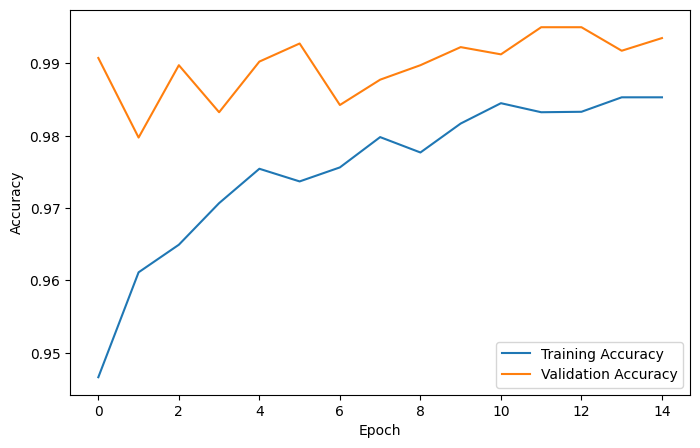

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(model_history.history['accuracy'],label='Training Accuracy')
plt.plot(model_history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

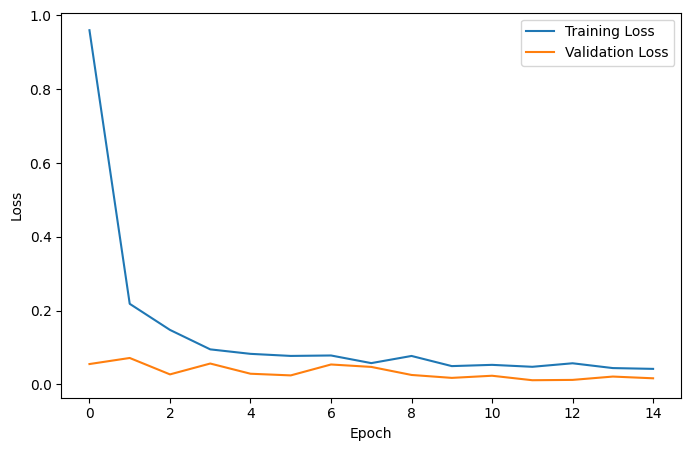

In [18]:
plt.figure(figsize=(8,5))

plt.plot(model_history.history['loss'],label='Training Loss')
plt.plot(model_history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - accuracy: 0.9840 - loss: 0.0436
Test Loss: 0.04360845312476158
Test Accuracy: 0.984000027179718


In [21]:
# predict output
import pandas as pd 
import numpy as np
class_names = ["cat", "dog"]
y_true = []
X=[]
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    X.extend(images)
y_true = np.array(y_true)
print("Actual :",class_names[y_true[1]])
y_pred_prob = model.predict(test_ds)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
print("Predicted :",class_names[y_pred[1]])

Actual : cat
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step
Predicted : cat


In [22]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2500
           1       0.98      0.99      0.98      2500

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



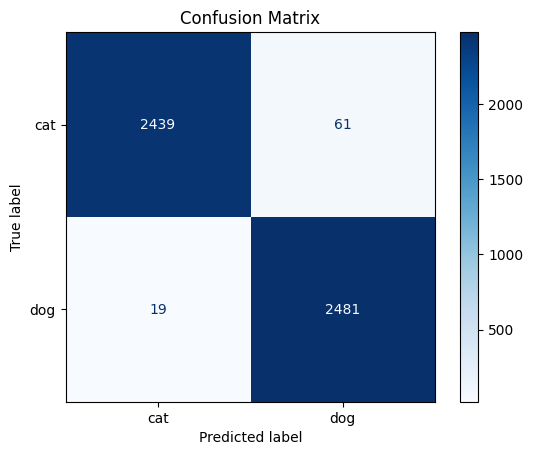

In [23]:
# print confusion matrix

ConfusionMatrixDisplay.from_predictions(
   y_true,y_pred,
    display_labels=class_names,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

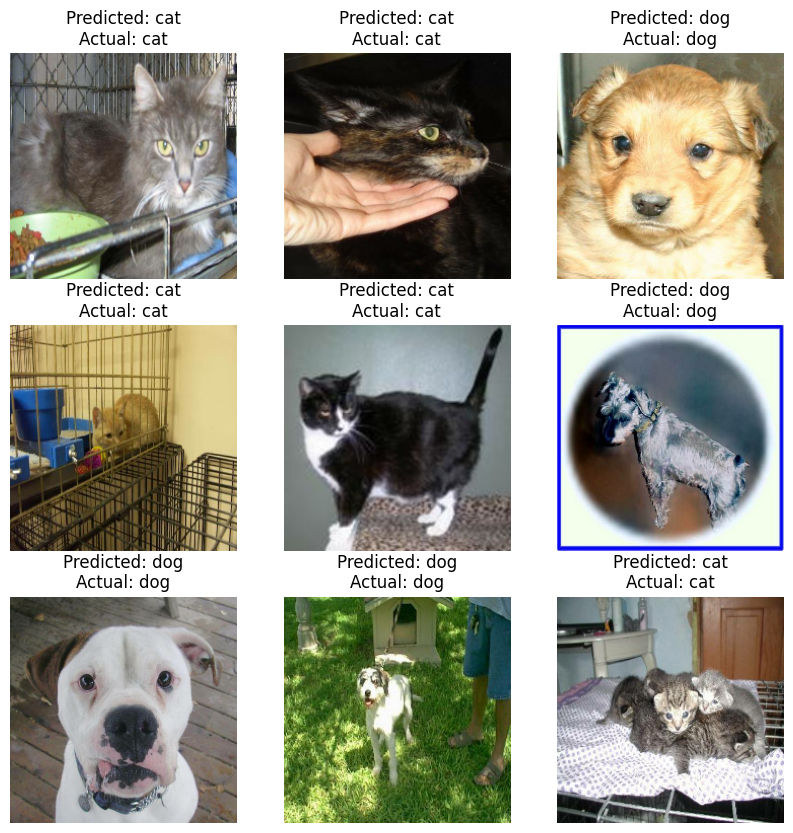

In [24]:
import matplotlib.pyplot as plt
import numpy as np

images_list = []
labels_list = []

for images, labels in test_ds:
    images_list.extend(images.numpy())
    labels_list.extend(labels.numpy())

images_list = np.array(images_list)
labels_list = np.array(labels_list)


plt.figure(figsize=(10,10))

for i in range(9):
    index = np.random.randint(len(images_list))

    plt.subplot(3,3,i+1)
    plt.imshow(images_list[index].astype("uint8"))

    plt.title(
        f"Predicted: {class_names[y_pred[index]]}\n"
        f"Actual: {class_names[labels_list[index]]}"
    )

    plt.axis("off")

plt.show()

In [25]:
import os
print(os.listdir())

['best_model.keras', '.virtual_documents', 'pretained_VGG-model.keras']


In [26]:
from IPython.display import FileLink

FileLink("best_model.keras")

/kaggle/working/best_model.keras